<a href="https://colab.research.google.com/github/EconByte/EconByte/blob/main/PS2_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Set 2: Linear Time Series & VAR Models
**Applied Macroeconometrics**

Fill in every `___` placeholder and write your answers in the **Your Answer** markdown cells.

> **Before you start:** make sure `2026-03-QD.csv` is in the same folder as this notebook.

In [ ]:
# Install required packages (run once if any import fails)
!pip install statsmodels pandas numpy matplotlib --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('2026-03-QD.csv').drop([0, 1])
for col in ['GDPC1', 'PCECC96', 'DPIC96', 'UNRATE', 'FEDFUNDS', 'CPIAUCSL']:
    df[col] = df[col].astype(float)

# Log-growth rates for Section 2 (VAR)
df['GDPC1_g']   = np.log(df['GDPC1']).diff()
df['PCECC96_g'] = np.log(df['PCECC96']).diff()
df['DPIC96_g']  = np.log(df['DPIC96']).diff()
gdp  = df['GDPC1_g'].dropna().reset_index(drop=True)
cons = df['PCECC96_g'].dropna().reset_index(drop=True)
inc  = df['DPIC96_g'].dropna().reset_index(drop=True)

# Unemployment rate level for Section 1 (AR)
unrate = df['UNRATE'].dropna().reset_index(drop=True)

print(f"Sample size T = {len(unrate)}")
print(f"UNRATE: {unrate.min():.1f}% – {unrate.max():.1f}%, last = {unrate.iloc[-1]:.1f}%")

Sample size T = 268
UNRATE: 3.4% – 13.0%, last = 4.5%


---
## Section 1: Autoregressive (AR) Models

An AR($p$) model expresses the current value as a linear function of its own $p$ most recent values:

$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t, \qquad \varepsilon_t \sim \text{WN}(0,\sigma^2)$$

The process is **covariance-stationary** if all roots of $1 - \phi_1 z - \cdots - \phi_p z^p = 0$ lie *outside* the unit circle.

We first survey four ACF/PACF patterns (Q1.1), then build a full AR model for the **Unemployment Rate (UNRATE)** — a series with clear AR persistence (Q1.2–Q1.4).

> **ACF/PACF identification rules** *(not covered in the lecture slides — read before Q1.1)*
>
> | Pattern | ACF | PACF | Suggested model |
> |---------|-----|------|-----------------|
> | **AR(p)** | Tails off (geometric decay) | Cuts off sharply after lag $p$ | AR($p$) |
> | **MA(q)** | Cuts off sharply after lag $q$ | Tails off | MA($q$) |
> | **ARMA(p,q)** | Tails off | Tails off | ARMA($p$,$q$) |
> | **White noise** | All bars within the 95% band | All bars within the 95% band | No model needed |

### Question 1.1 — ACF/PACF Patterns in Practice

The table above describes four theoretical patterns.
Below you will observe **all four** using real FRED-QD series.

For each series: run the code cell to produce ACF and PACF plots (12 lags), then record your interpretation in the answer cell.

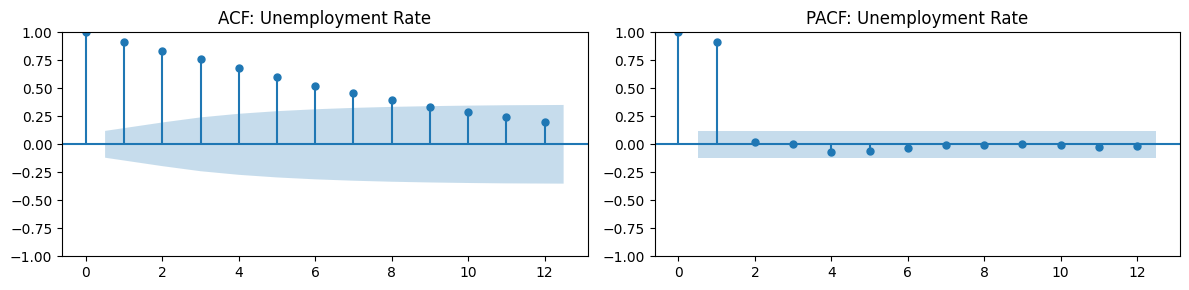

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Series 1: Unemployment Rate (level)
series1 = df['UNRATE'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
# TODO: Plot ACF of series1 for 12 lags on axes[0]
plot_acf(series1, lags=12, ax=axes[0], title='ACF: Unemployment Rate')
# TODO: Plot PACF of series1 for 12 lags on axes[1]
plot_pacf(series1, lags=12, ax=axes[1], title='PACF: Unemployment Rate')
plt.tight_layout(); plt.show()

**Your Answer — Series 1 (Unemployment Rate):**

*Which pattern do you observe? What model would you suggest?*

> YOUR ANSWER HERE

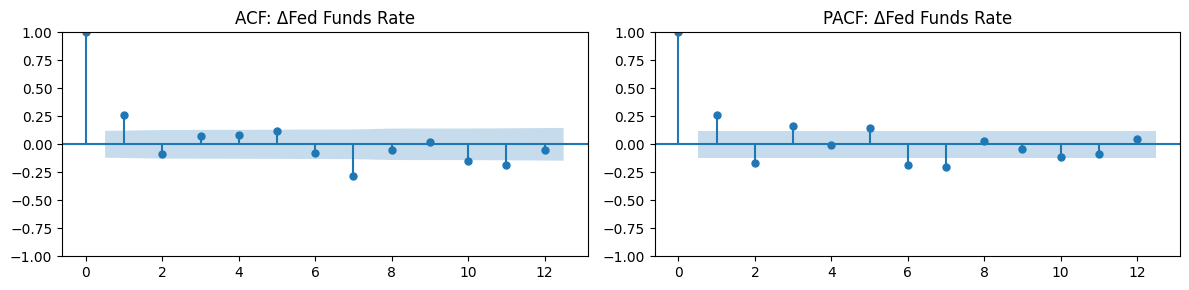

In [ ]:
# Series 2: Fed Funds Rate — first difference
series2 = df['FEDFUNDS'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
# TODO: Plot ACF of series2 for 12 lags on axes[0]
plot_acf(series2, lags=12, ax=axes[0], title='ACF: ΔFed Funds Rate')
# TODO: Plot PACF of series2 for 12 lags on axes[1]
plot_pacf(series2, lags=12, ax=axes[1], title='PACF: ΔFed Funds Rate')
plt.tight_layout(); plt.show()

**Your Answer — Series 2 (ΔFed Funds Rate):**

*Which pattern do you observe? What model would you suggest?*

> YOUR ANSWER HERE

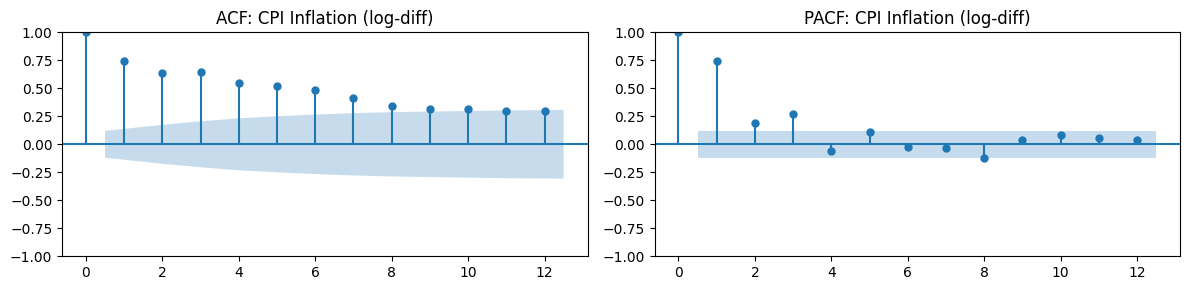

In [ ]:
# Series 3: CPI — log first difference (quarterly inflation rate)
series3 = np.log(df['CPIAUCSL']).diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
# TODO: Plot ACF of series3 for 12 lags on axes[0]
plot_acf(series3, lags=12, ax=axes[0], title='ACF: CPI Inflation (log-diff)')
# TODO: Plot PACF of series3 for 12 lags on axes[1]
plot_pacf(series3, lags=12, ax=axes[1], title='PACF: CPI Inflation (log-diff)')
plt.tight_layout(); plt.show()

**Your Answer — Series 3 (CPI Inflation):**

*Which pattern do you observe? What model would you suggest?*

> YOUR ANSWER HERE

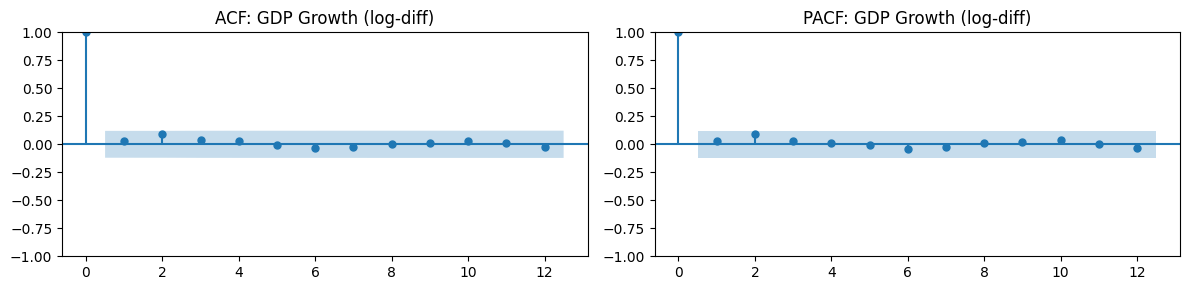

In [ ]:
# Series 4: Real GDP — log first difference (growth rate)
series4 = gdp   # already created in the setup cell

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
# TODO: Plot ACF of series4 for 12 lags on axes[0]
plot_acf(series4, lags=12, ax=axes[0], title='ACF: GDP Growth (log-diff)')
# TODO: Plot PACF of series4 for 12 lags on axes[1]
plot_pacf(series4, lags=12, ax=axes[1], title='PACF: GDP Growth (log-diff)')
plt.tight_layout(); plt.show()

**Your Answer — Series 4 (GDP Growth):**

*Which pattern do you observe? What model would you suggest?*

> YOUR ANSWER HERE

**Summary Table — fill in your conclusions:**

| # | Series | Transformation | Pattern | Suggested model |
|---|--------|---------------|---------|-----------------|
| 1 | Unemployment Rate | Level | ? | ? |
| 2 | ΔFed Funds Rate | First diff | ? | ? |
| 3 | CPI Inflation | Log-diff | ? | ? |
| 4 | GDP Growth | Log-diff | ? | ? |

### Question 1.2 — Lag Order Selection

From Q1.1, the Unemployment Rate shows a clear **AR pattern**.
Formally compare AR models of orders $p \in \{1, 2, 3, 4\}$ using AIC and BIC (lower = better).

Which order does each criterion prefer? If they disagree, which would you choose and why?

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

print(f"{'p':>4}  {'AIC':>10}  {'BIC':>10}")

# TODO: Loop p = 1..4, fit AutoReg(unrate, lags=p, old_names=False), print AIC and BIC
for p in range(1, 5):
    res = AutoReg(unrate, lags=p, old_names=False).fit()
    print(f"{p:>4}  {res.aic:>10.2f}  {res.bic:>10.2f}")

# TODO: Set p_chosen to your preferred lag order
# p_chosen = ___
# print(f"\nSelected AR order: p = {p_chosen}")

   p         AIC         BIC
   1      567.93      578.70
   2      567.59      581.93
   3      568.47      586.37
   4      567.96      589.41


**Your Answer (1.2):**

*Which order does AIC prefer? BIC? If they disagree, which do you choose and why?*

> YOUR ANSWER HERE

### Question 1.3 — Model Estimation and Stationarity

Estimate the AR model with the lag order selected in Q1.2.

**(a)** Are the estimated lag coefficients statistically significant at the 5% level?
**(b)** Is the model covariance-stationary? Check whether the modulus of all AR roots exceeds 1.

In [ ]:
# TODO: Fit AutoReg with p_chosen lags on unrate
ar_res = AutoReg(unrate, lags=2, old_names=False).fit()
print(ar_res.summary())


# TODO: Print the modulus of all AR roots (each must be > 1 for stationarity)
print("\nAR root moduli:", np.abs(ar_res.roots))

                            AutoReg Model Results                             
Dep. Variable:                 UNRATE   No. Observations:                  268
Model:                     AutoReg(2)   Log Likelihood                -279.797
Method:               Conditional MLE   S.D. of innovations              0.693
Date:                Mon, 11 May 2026   AIC                            567.594
Time:                        13:20:14   BIC                            581.928
Sample:                             2   HQIC                           573.352
                                  268                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5025      0.158      3.185      0.001       0.193       0.812
UNRATE.L1      0.8927      0.061     14.593      0.000       0.773       1.013
UNRATE.L2      0.0212      0.061      0.345      0.7

**Your Answer (1.3):**

*(a) Are the lag coefficients significant at 5%?*

> YOUR ANSWER HERE

*(b) Are all |root| > 1? Is the process covariance-stationary?*

> YOUR ANSWER HERE

### Question 1.4 — Forecasting

Use the fitted AR model to forecast the **Unemployment Rate** for the next **8 quarters**.
Plot actual data, in-sample fitted values, and the out-of-sample forecast on the same figure.

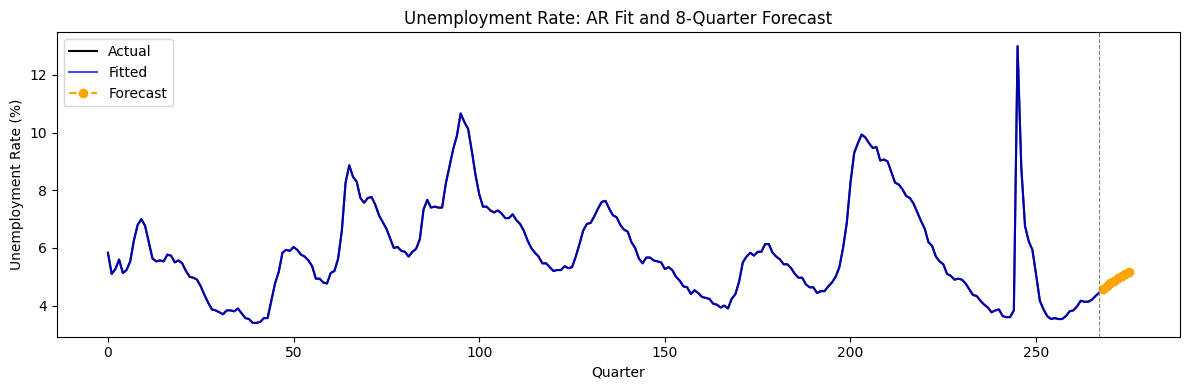

In [ ]:
n = len(unrate)

# TODO: Generate an 8-quarter out-of-sample forecast
#   Hint: ar_res.predict(start=n, end=n+7)
forecast = ar_res.predict(start=n, end=n+7)

plt.figure(figsize=(12, 4))
plt.plot(unrate, label='Actual', color='black')

# TODO: Plot in-sample fitted values in blue (ar_res.fittedvalues)
plt.plot(unrate, label='Fitted', color='blue', alpha=0.7)

# TODO: Plot the 8-quarter forecast as an orange dashed line
plt.plot(range(n, n + 8), forecast, 'o--', color='orange', label='Forecast')

plt.axvline(n - 1, color='gray', linestyle='--', linewidth=0.8)
plt.title('Unemployment Rate: AR Fit and 8-Quarter Forecast')
plt.xlabel('Quarter')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 2: Vector Autoregressive (VAR) Models

The **structural VAR(1)** model (lecture notation) is:
$$B_0 y_t = B_1 y_{t-1} + u_t, \qquad E[u_t u_t'] = D \text{ (diagonal)}$$

Pre-multiplying by $B_0^{-1}$ gives the **reduced-form VAR**:
$$y_t = \Phi_1 y_{t-1} + \upsilon_t, \qquad \upsilon_t \sim \text{WN}(\mathbf{0}, V)$$

where $\upsilon_t = B_0^{-1}u_t$ and $V = B_0^{-1}DB_0^{-1\prime}$.

We model $y_t = [\Delta y_t^{\text{GDP}},\, \Delta y_t^{\text{Cons}},\, \Delta y_t^{\text{Inc}}]'$ using the log-growth rates from PS1.

### Question 2.1 — Data Assembly

Combine the three growth-rate series into a single DataFrame with columns `gdp`, `cons`, `inc`.

In [ ]:
df_var = pd.DataFrame({
    'gdp':  df['GDPC1_g'],
    'cons': df['PCECC96_g'],
    'inc':  df['DPIC96_g']
}).dropna()

print(f"Shape: {df_var.shape}")
df_var.head()

Shape: (267, 3)


,gdp,cons,inc
3,0.022284,0.015326,0.015998
4,0.000697,0.010393,-0.001351
5,0.002846,0.001126,0.007097
6,0.022237,0.009521,0.011476
7,-0.005398,0.012535,0.006447


### Question 2.2 — Lag Order Selection

Use the VAR's built-in information criteria to compare $p = 1, \ldots, 6$.
Report the table and state which order you select and why.

In [ ]:
from statsmodels.tsa.api import VAR

var_model = VAR(df_var)
order_result = var_model.select_order(maxlags=6)
print(order_result.summary())

p_var = 1   # BIC prefers p=1; AIC may suggest p=2
print(f"\nSelected VAR order: p = {p_var}")

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -27.99      -27.95   6.963e-13      -27.98
1      -28.16      -27.99   5.899e-13      -28.09
2      -28.31      -28.02   5.096e-13      -28.19
3      -28.48     -28.07*   4.290e-13     -28.31*
4      -28.50      -27.97   4.201e-13      -28.28
5     -28.51*      -27.85  4.161e-13*      -28.24
6      -28.50      -27.73   4.178e-13      -28.19
-------------------------------------------------

Selected VAR order: p = 1


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


**Your Answer (2.2):**

*Which lag order do AIC and BIC prefer? Which do you choose and why?*

> YOUR ANSWER HERE

### Question 2.3 — VAR Estimation

Fit the VAR($p$) model and inspect the `gdp` equation.

**(a)** Interpret the coefficient on `inc.L1` in words.
**(b)** Does last quarter's own GDP growth (`gdp.L1`) significantly predict current GDP growth?

In [ ]:
# TODO: Fit the VAR model with p_var lags
var_res = var_model.fit(___)
print(var_res.summary())

**Your Answer (2.3):**

*(a) Interpret the coefficient on `inc.L1` in the `gdp` equation.*

> YOUR ANSWER HERE

*(b) Does `gdp.L1` significantly predict current GDP growth?*

> YOUR ANSWER HERE

### Question 2.4 — Hand Calculation: Cholesky Decomposition

To compute **orthogonalised** impulse responses, `statsmodels` decomposes the estimated VAR residual covariance matrix $\widehat{V}$ as:

$$\widehat{V} = SS', \qquad S \text{ lower triangular}$$

Suppose the estimated covariance matrix (simplified 2-variable example) is:

$$\widehat{V} = \begin{pmatrix} 4 & 2 \\ 2 & 5 \end{pmatrix}$$

**(a)** Compute the lower triangular Cholesky factor $S$ such that $SS' = \widehat{V}$. Use the formulas:
$$s_{11} = \sqrt{v_{11}}, \qquad s_{21} = \frac{v_{21}}{s_{11}}, \qquad s_{22} = \sqrt{v_{22} - s_{21}^2}$$

**(b)** Since $V = B_0^{-1}DB_0^{-1\prime}$ (lecture slides), it follows that $S = B_0^{-1}D^{1/2}$, where $B_0^{-1}$ is lower triangular with **1s on the diagonal** and $D$ is the diagonal covariance matrix of structural shocks $u_t$. Identify $B_0^{-1}$ and $D$.

**Your Answer (2.4):**

*(a) Show your calculation of S:*

> YOUR ANSWER HERE

*(b) Identify $B_0^{-1}$ and $D$:*

> YOUR ANSWER HERE

### Question 2.5 — Impulse Response Functions (IRF)

Compute and plot the orthogonalised impulse responses for 12 periods.

The **Cholesky ordering** (`gdp` → `cons` → `inc`) imposes a recursive structure on $B_0^{-1}$: a shock to GDP ($u_t^{\text{GDP}}$) can immediately affect consumption and income, but not vice versa.

**(a)** Describe the response of **GDP growth** to a one-standard-deviation structural shock in **income growth** ($u_t^{\text{Inc}}$). Does the effect persist or die out quickly?

**(b)** What does placing `inc` last in the Cholesky ordering imply about the contemporaneous relationship between income and GDP?

In [ ]:
# TODO: Compute orthogonalised IRFs for 12 periods
irf = var_res.irf(___)

# TODO: Plot with orth=True for Cholesky orthogonalisation
irf.plot(orth=___)
plt.tight_layout()
plt.show()

**Your Answer (2.5):**

*(a) Describe the GDP response to a one-std structural shock in income. Does it persist?*

> YOUR ANSWER HERE

*(b) What does placing `inc` last imply about the structure of $B_0^{-1}$?*

> YOUR ANSWER HERE

### Question 2.6 — Granger Causality Tests

**Granger causality**: does knowing the past of $X$ improve the forecast of $Y$, beyond $Y$'s own past?

Formally, for a VAR($p$), test $H_0$: all coefficients on lags of $X$ in $Y$'s equation of $\Phi_1, \ldots, \Phi_p$ are jointly zero. Reject at 5% if $p\text{-value} < 0.05$.

**(a)** Test whether `inc` Granger-causes `gdp`, and vice versa. Interpret both results.

**(b)** Granger causality is *not* the same as economic causality. Explain in 1–2 sentences what Granger causality actually measures and why this distinction matters.

In [ ]:
# TODO: Test whether 'inc' Granger-causes 'gdp'
gc1 = var_res.test_causality(___, [___], kind='wald')
print("Does 'inc' Granger-cause 'gdp'?")
print(gc1.summary())

# TODO: Test whether 'gdp' Granger-causes 'inc'
gc2 = var_res.test_causality(___, [___], kind='wald')
print("\nDoes 'gdp' Granger-cause 'inc'?")
print(gc2.summary())

**Your Answer (2.6):**

*(a) Report the p-values and state your conclusions at the 5% level.*

> YOUR ANSWER HERE

*(b) What does Granger causality actually measure, and why does it differ from economic causality?*

> YOUR ANSWER HERE